   Feature1  Feature2  Label
0  0.496714 -0.138264      0
1  0.647689  1.523030      0
2 -0.234153 -0.234137      0
3  1.579213  0.767435      0
4 -0.469474  0.542560      0
Dataset Shape: (300, 3)

Columns:
Index(['Feature1', 'Feature2', 'Label'], dtype='object')

Missing Values:
Feature1    0
Feature2    0
Label       0
dtype: int64
Features Shape: (300, 2)
Labels Shape: (300,)
Transformed Shape: (300, 1)
        LD1  Class
0 -1.965559      0
1 -0.188563      0
2 -2.256168      0
3 -0.736318      0
4 -1.505039      0


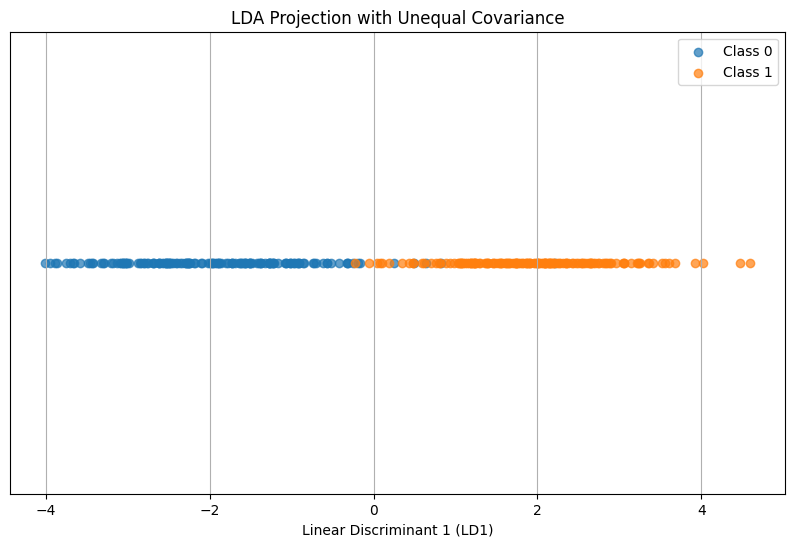

In [3]:
# LDA on Unequal Covariance Dataset — Step-by-Step Jupyter Notebook

## Step 1: Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler


# Step 2: Load the Dataset


# Load dataset
file_path = 'lda_unequal_covariance.csv'
df = pd.read_csv(file_path)

# Display first 5 rows
print(df.head())


# Step 3: Check Dataset Information


# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


# Step 4: Separate Features and Labels


# Features
X = df.iloc[:, :-1]

# Target labels
y = df.iloc[:, -1]

print("Features Shape:", X.shape)
print("Labels Shape:", y.shape)


# Step 5: Standardize the Features

#LDA works better when features are scaled.


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Step 6: Apply Linear Discriminant Analysis (LDA)


# Create LDA model
lda = LinearDiscriminantAnalysis(n_components=1)

# Transform data
X_lda = lda.fit_transform(X_scaled, y)

print("Transformed Shape:", X_lda.shape)


# Step 7: Create DataFrame for Visualization

# Create new dataframe
lda_df = pd.DataFrame()
lda_df['LD1'] = X_lda.flatten()
lda_df['Class'] = y.values

print(lda_df.head())


# Step 8: Plot LDA Projection


plt.figure(figsize=(10, 6))

# Plot each class separately
for cls in lda_df['Class'].unique():
    subset = lda_df[lda_df['Class'] == cls]
    plt.scatter(
        subset['LD1'],
        np.zeros(len(subset)),
        label=f'Class {cls}',
        alpha=0.7
    )

plt.title('LDA Projection with Unequal Covariance')
plt.xlabel('Linear Discriminant 1 (LD1)')
plt.yticks([])
plt.legend()
plt.grid(True)
plt.show()



In [ ]:

# Step 9: Interpretation of Results

## 1. Do classes overlap after LDA projection?

Yes. Even after applying LDA, the classes still overlap in some regions along the LD1 axis.

This means the projection does not completely separate the classes.

## 2. What does this tell you about covariance assumptions?

LDA assumes that all classes share the same covariance matrix.

The overlap suggests that this assumption is violated because the actual covariance structures of the classes are different.


## 3. How are the spreads of the two classes different?

The spreads of the classes are unequal:

* One class is tightly clustered.
* The other class is more spread out.

This difference indicates unequal covariance among classes.


## 4. Why does LDA struggle when covariance differs?

LDA creates a linear decision boundary using a shared covariance matrix.

When covariance differs:

* The optimal boundary becomes nonlinear.
* A single linear projection cannot perfectly separate the classes.
* This causes overlap and lower classification performance.

In such cases, Quadratic Discriminant Analysis (QDA) is usually more effective because it allows each class to have its own covariance matrix.

---

# Final Conclusion

This experiment shows that LDA works best when class covariances are similar.

When covariance matrices differ significantly:

* LDA projections show overlap.
* Class spreads become uneven.
* Linear separation becomes difficult.

Therefore, unequal covariance is one of the main limitations of LDA.
